In [ ]:
import lightkurve as lk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# Create output directory
os.makedirs("processed_lightcurves", exist_ok=True)


In [ ]:
koi_url = ("https://exoplanetarchive.ipac.caltech.edu/"
           "cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&format=csv")
koi_df = pd.read_csv(koi_url)

confirmed = koi_df[(koi_df['koi_disposition'] == 'CONFIRMED') &
                   (~koi_df['koi_period'].isna()) &
                   (~koi_df['koi_time0bk'].isna())].reset_index(drop=True)

print(f"Confirmed KOIs count: {len(confirmed)}")
confirmed[['kepid','koi_period','koi_time0bk','koi_duration']].head()


In [ ]:
def preprocess_lightcurve(lc):
    lc = lc.remove_nans()
    lc = lc.flatten(window_length=401)
    lc = lc.normalize()
    return lc


In [ ]:
max_targets = 500
saved = 0
skipped = 0

for _, row in tqdm(confirmed.iterrows(), total=len(confirmed)):
    if saved >= max_targets:
        break
    try:
        kic_id = int(row['kepid'])
        search = lk.search_lightcurve(f"KIC {kic_id}", mission="Kepler", cadence="long")

        # Check data exists
        if search is None or len(search.table) == 0:
            print(f"No data found for KIC {kic_id}")
            skipped += 1
            continue

        # Download and stitch
        lc_collection = search.download_all()
        lc = lc_collection.stitch()

        #access PDCSAP, fallback to SAP
        if hasattr(lc, 'PDCSAP_FLUX') and lc.PDCSAP_FLUX is not None:
            lc_used = lc.PDCSAP_FLUX
        else:
            print(f"KIC {kic_id} has no PDCSAP_FLUX, using SAP_FLUX instead.")
            lc_used = lc.SAP_FLUX

        # Skip if still invalid
        if lc_used is None:
            skipped += 1
            continue

        # Preprocess
        lc_clean = preprocess_lightcurve(lc_used)

        # Save
        fname = f"processed_lightcurves/KIC_{kic_id}.npz"
        np.savez(fname, time=lc_clean.time.value, flux=lc_clean.flux.value)

        saved += 1

    except Exception as e:
        print(f"❌ Error for KIC {kic_id}: {e}")
        skipped += 1
        continue

print(f"\n✅ Saved: {saved} light curves.")
print(f"⏭ Skipped: {skipped} targets.")


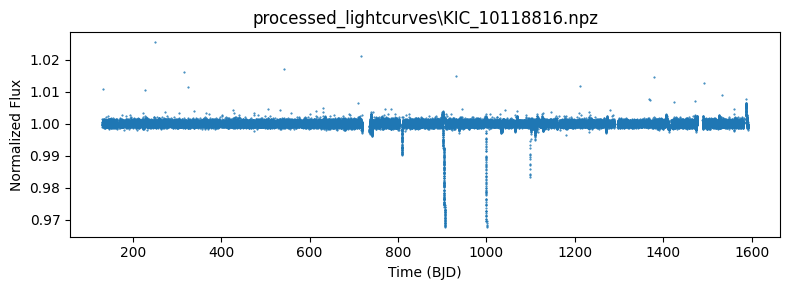

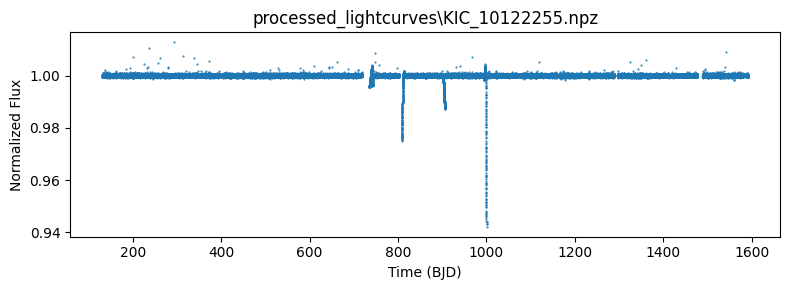

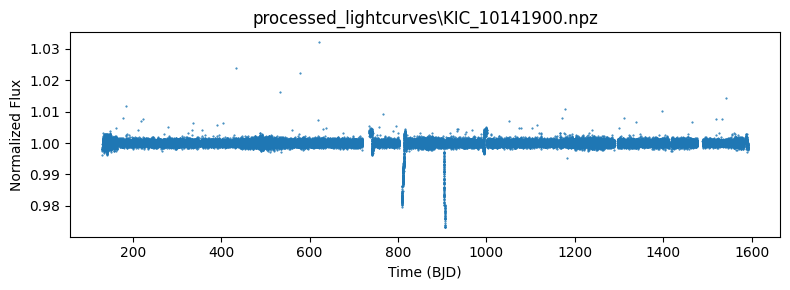

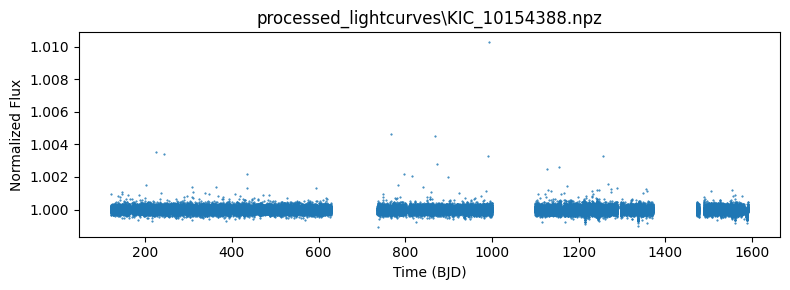

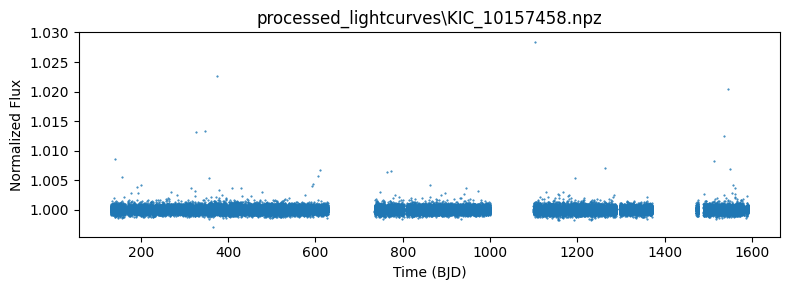

In [6]:
from glob import glob
import numpy as np  
import matplotlib.pyplot as plt
for file in glob("processed_lightcurves/*.npz")[:5]:
    data = np.load(file)
    plt.figure(figsize=(8,3))
    plt.plot(data['time'], data['flux'], '.', ms=1)
    plt.title(file.split('/')[-1])
    plt.xlabel("Time (BJD)"); plt.ylabel("Normalized Flux")
    plt.tight_layout()
    plt.show()
